## Q7 - Image Zooming


### 1 - Import Required Libraries


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd


### 2 - Set Input and Output Paths


In [2]:
base_dir = Path("../data/raw/a1q8images")
out_dir = Path("../results/q07")
out_dir.mkdir(parents=True, exist_ok=True)

image_pairs = [
    ("im01.png", "im01small.png"),
    ("im02.png", "im02small.png"),
    ("im03.png", "im03small.png"),
    ("taylor.jpg", "taylor_small.jpg"),
    ("taylor.jpg", "taylor_very_small.jpg"),
]

print("Image folder:", base_dir.resolve())
print("Output folder:", out_dir.resolve())
print("Image pairs to test:")
for pair in image_pairs:
    print(pair)


Image folder: D:\MSc in AI\1YQ3\CV\Assignment_1\data\raw\a1q8images
Output folder: D:\MSc in AI\1YQ3\CV\Assignment_1\results\q07
Image pairs to test:
('im01.png', 'im01small.png')
('im02.png', 'im02small.png')
('im03.png', 'im03small.png')
('taylor.jpg', 'taylor_small.jpg')
('taylor.jpg', 'taylor_very_small.jpg')


### 3 - Define Nearest-Neighbor Interpolation

In [3]:
def resize_nearest(img, scale_x, scale_y):
    h, w = img.shape[:2]
    new_h = int(round(h * scale_y))
    new_w = int(round(w * scale_x))

    if img.ndim == 2:
        out = np.zeros((new_h, new_w), dtype=img.dtype)
    else:
        out = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)

    for y_new in range(new_h):
        for x_new in range(new_w):
            y = min(int(round(y_new / scale_y)), h - 1)
            x = min(int(round(x_new / scale_x)), w - 1)
            out[y_new, x_new] = img[y, x]

    return out


### 4 - Define Bilinear Interpolation

In [4]:
def resize_bilinear(img, scale_x, scale_y):
    h, w = img.shape[:2]
    new_h = int(round(h * scale_y))
    new_w = int(round(w * scale_x))

    if img.ndim == 2:
        out = np.zeros((new_h, new_w), dtype=np.float32)
    else:
        out = np.zeros((new_h, new_w, img.shape[2]), dtype=np.float32)

    for y_new in range(new_h):
        for x_new in range(new_w):
            y = y_new / scale_y
            x = x_new / scale_x

            y0 = int(np.floor(y))
            x0 = int(np.floor(x))
            y1 = min(y0 + 1, h - 1)
            x1 = min(x0 + 1, w - 1)

            dy = y - y0
            dx = x - x0

            if img.ndim == 2:
                top = (1 - dx) * img[y0, x0] + dx * img[y0, x1]
                bottom = (1 - dx) * img[y1, x0] + dx * img[y1, x1]
                out[y_new, x_new] = (1 - dy) * top + dy * bottom
            else:
                top = (1 - dx) * img[y0, x0, :] + dx * img[y0, x1, :]
                bottom = (1 - dx) * img[y1, x0, :] + dx * img[y1, x1, :]
                out[y_new, x_new, :] = (1 - dy) * top + dy * bottom

    return np.clip(out, 0, 255).astype(img.dtype)


### 5 - Define Normalized SSD Function

In [5]:
def normalized_ssd(img1, img2):
    diff = img1.astype(np.float32) - img2.astype(np.float32)
    ssd = np.sum(diff ** 2)
    return ssd / img1.size


### 6 - Define Size Matching Function

In [6]:
def match_target_size(img, target_h, target_w):
    h, w = img.shape[:2]

    if img.ndim == 2:
        out = np.zeros((target_h, target_w), dtype=img.dtype)
    else:
        out = np.zeros((target_h, target_w, img.shape[2]), dtype=img.dtype)

    copy_h = min(h, target_h)
    copy_w = min(w, target_w)

    out[:copy_h, :copy_w] = img[:copy_h, :copy_w]
    return out


### 7 - Process All Image Pairs


Pair: im01.png  <-  im01small.png
Scale factor x: 4.0000
Scale factor y: 4.0000
Normalized SSD (Nearest Neighbor): 255.2957
Normalized SSD (Bilinear): 200.2451


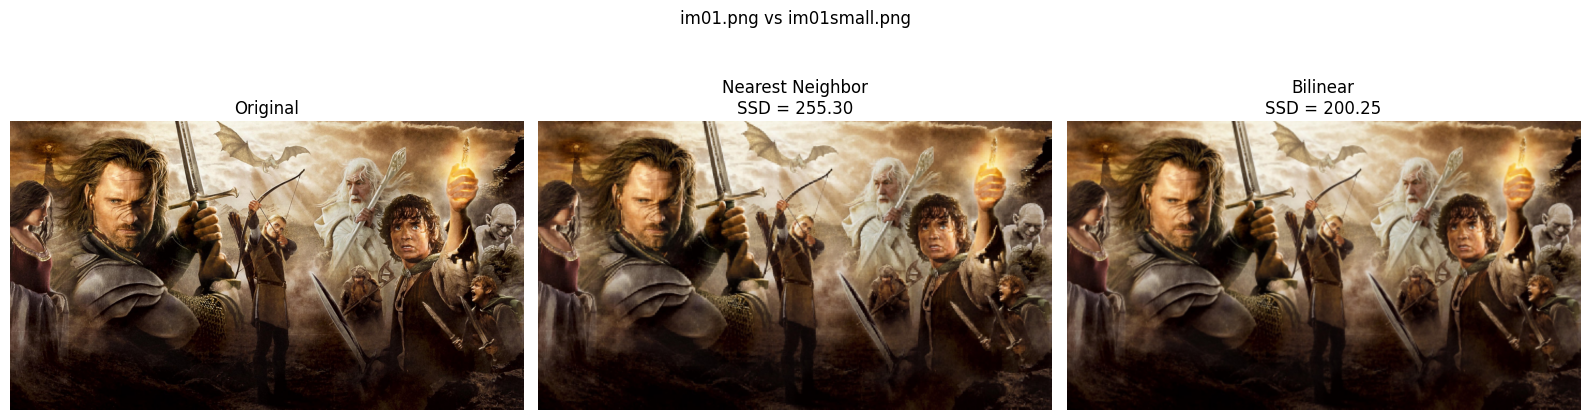


Pair: im02.png  <-  im02small.png
Scale factor x: 4.0000
Scale factor y: 4.0000
Normalized SSD (Nearest Neighbor): 64.6294
Normalized SSD (Bilinear): 48.9607


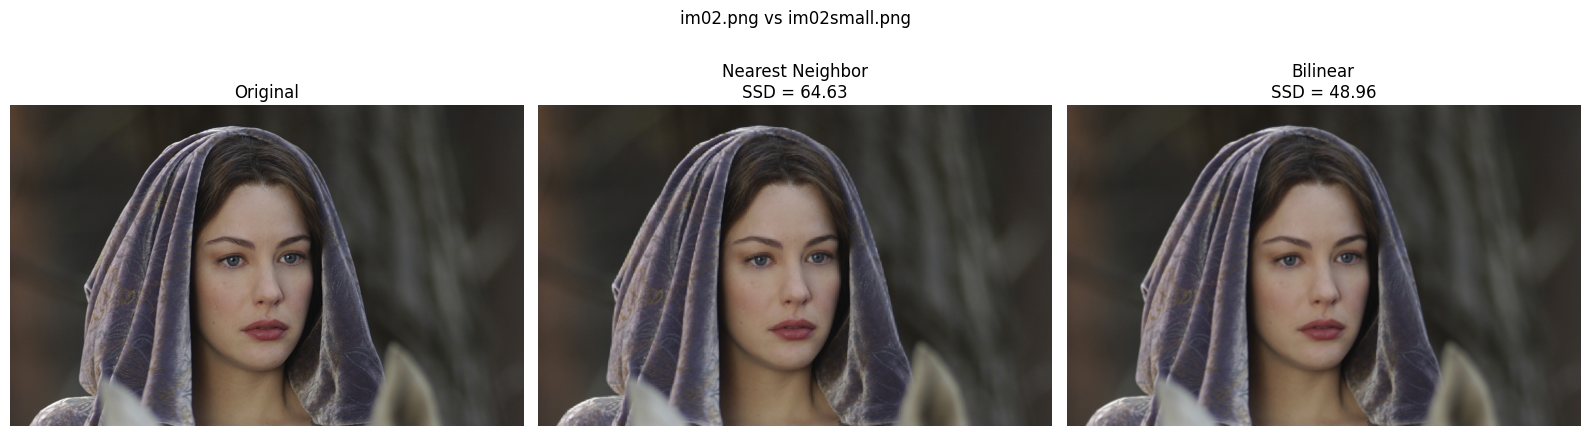


Pair: im03.png  <-  im03small.png
Scale factor x: 4.0000
Scale factor y: 3.9973
Normalized SSD (Nearest Neighbor): 147.7655
Normalized SSD (Bilinear): 113.5661


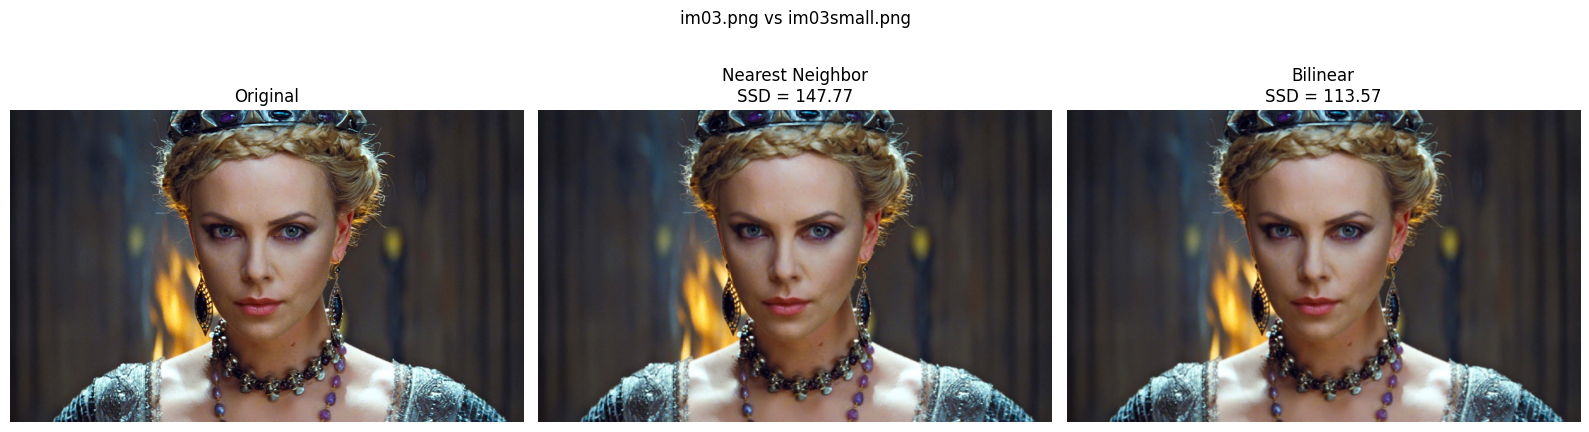


Pair: taylor.jpg  <-  taylor_small.jpg
Scale factor x: 5.0000
Scale factor y: 5.0000
Normalized SSD (Nearest Neighbor): 320.0882
Normalized SSD (Bilinear): 285.2136


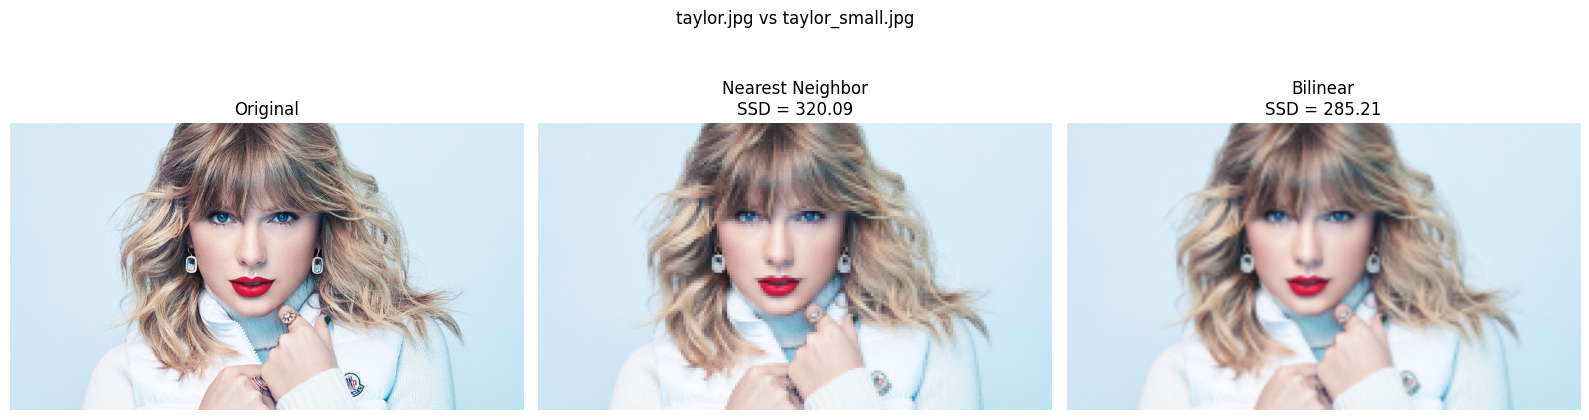


Pair: taylor.jpg  <-  taylor_very_small.jpg
Scale factor x: 20.0000
Scale factor y: 20.0000
Normalized SSD (Nearest Neighbor): 737.8096
Normalized SSD (Bilinear): 654.6263


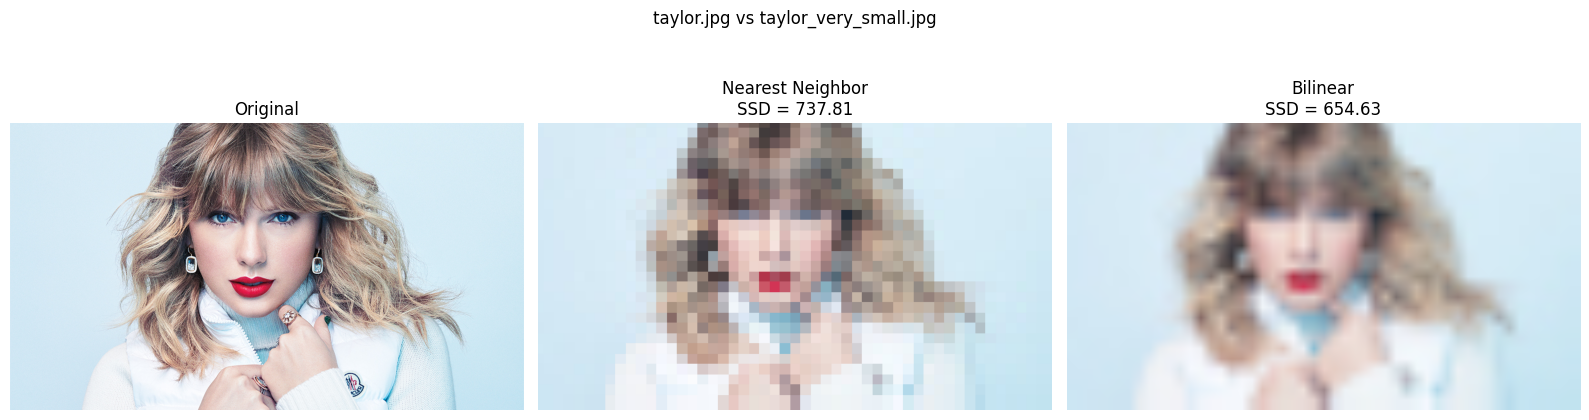

In [7]:
results = []

for original_name, small_name in image_pairs:
    original_path = base_dir / original_name
    small_path = base_dir / small_name

    original = cv2.imread(str(original_path), cv2.IMREAD_COLOR)
    small = cv2.imread(str(small_path), cv2.IMREAD_COLOR)

    if original is None:
        raise FileNotFoundError(f"Could not load original image: {original_path}")
    if small is None:
        raise FileNotFoundError(f"Could not load small image: {small_path}")

    h_orig, w_orig = original.shape[:2]
    h_small, w_small = small.shape[:2]

    scale_y = h_orig / h_small
    scale_x = w_orig / w_small

    nearest_up = resize_nearest(small, scale_x, scale_y)
    bilinear_up = resize_bilinear(small, scale_x, scale_y)

    nearest_up = match_target_size(nearest_up, h_orig, w_orig)
    bilinear_up = match_target_size(bilinear_up, h_orig, w_orig)

    ssd_nearest = normalized_ssd(original, nearest_up)
    ssd_bilinear = normalized_ssd(original, bilinear_up)

    pair_tag = f"{Path(original_name).stem}__{Path(small_name).stem}"

    cv2.imwrite(str(out_dir / f"{pair_tag}_nearest.png"), nearest_up)
    cv2.imwrite(str(out_dir / f"{pair_tag}_bilinear.png"), bilinear_up)

    results.append(
        {
            "original": original_name,
            "small": small_name,
            "scale_factor_x": scale_x,
            "scale_factor_y": scale_y,
            "ssd_nearest": ssd_nearest,
            "ssd_bilinear": ssd_bilinear,
        }
    )

    print(f"\nPair: {original_name}  <-  {small_name}")
    print(f"Scale factor x: {scale_x:.4f}")
    print(f"Scale factor y: {scale_y:.4f}")
    print(f"Normalized SSD (Nearest Neighbor): {ssd_nearest:.4f}")
    print(f"Normalized SSD (Bilinear): {ssd_bilinear:.4f}")

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(nearest_up, cv2.COLOR_BGR2RGB))
    plt.title(f"Nearest Neighbor\nSSD = {ssd_nearest:.2f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(bilinear_up, cv2.COLOR_BGR2RGB))
    plt.title(f"Bilinear\nSSD = {ssd_bilinear:.2f}")
    plt.axis("off")

    plt.suptitle(f"{original_name} vs {small_name}")
    plt.tight_layout()
    plt.show()


### 8 - Create Summary Table

In [8]:
df = pd.DataFrame(results)
print("\nSummary of Results:")
print(df)



Summary of Results:
     original                  small  scale_factor_x  scale_factor_y  \
0    im01.png          im01small.png             4.0         4.00000   
1    im02.png          im02small.png             4.0         4.00000   
2    im03.png          im03small.png             4.0         3.99726   
3  taylor.jpg       taylor_small.jpg             5.0         5.00000   
4  taylor.jpg  taylor_very_small.jpg            20.0        20.00000   

   ssd_nearest  ssd_bilinear  
0   255.295685    200.245148  
1    64.629379     48.960667  
2   147.765457    113.566124  
3   320.088226    285.213623  
4   737.809570    654.626343  


### 9 - Save Summary CSV

In [9]:
summary_path = out_dir / "q07_ssd_results.csv"
df.to_csv(summary_path, index=False)

print(f"Saved summary CSV to: {summary_path}")
print(f"Saved reconstructed images to: {out_dir}")


Saved summary CSV to: ..\results\q07\q07_ssd_results.csv
Saved reconstructed images to: ..\results\q07


## Interpretation and Discussion

The zooming algorithm was tested on several image pairs consisting of a large original image and a smaller zoomed-out version. Each small image was upscaled back to the original size using nearest-neighbor interpolation and bilinear interpolation.

Nearest-neighbor interpolation is simple and fast, but it usually produces blocky edges and less smooth visual results. Bilinear interpolation computes each output pixel using weighted averages of nearby pixels, so the reconstructed image is usually smoother.

The normalized sum of squared differences (SSD) was used to compare each reconstructed image with its original version. A lower SSD indicates a better reconstruction. In most cases, bilinear interpolation is expected to produce lower SSD values than nearest-neighbor interpolation.

Some provided small images may not have exactly the same scaling ratio in both width and height because of rounding during downsampling. Therefore, separate horizontal and vertical scale factors were used.
